# Lasso Regression

Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a linear regression technique that prevents overfitting by adding an \(L1\) penalty to the cost function. It shrinks less significant feature coefficients exactly to zero, performing automatic feature selection and producing simpler, more interpretable models

## Import libraries and dataset


In [171]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

In [172]:
#Importing the dataset
df = pd.read_csv('/content/Advertising (1).csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Define variables and split into train and test set


In [173]:
X = df[['TV','Radio','Newspaper']] #Features(Independent variables)
y = df['Sales'] #Target(Dependent variable)

In [174]:
# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

##Apply lasso regression

In [175]:
alpha_value=3
lasso_model = Lasso(alpha=alpha_value, max_iter=5000) # Initialize Lasso model with a fixed alpha
lasso_model.fit(x_train, y_train) # Fit the model on the training data


MSE_train = mean_squared_error(y_train, lasso_model.predict(x_train))
r2_train = lasso_model.score(x_train, y_train)

# Print R2 scores
print(f"Alpha = {alpha_value}")
print(f"R2 Score (Train): {r2_train:.4f}")
print(f"MSE (Train): {MSE_train:.4f}")

Alpha = 3
R2 Score (Train): 0.9036
MSE (Train): 2.5285


In [176]:
print(f"Alpha = {lasso_model.alpha}")
print (pd.Series(lasso_model.coef_, index = X.columns))

Alpha = 3
TV           0.043802
Radio        0.187266
Newspaper    0.002768
dtype: float64


Plot coefficients vs column names

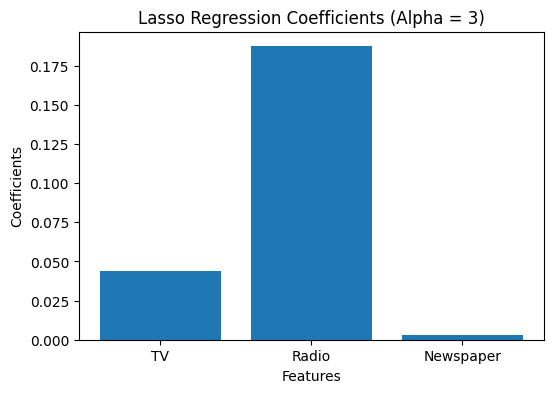

In [177]:
coefficients = lasso_model.coef_ #Store coefficients

plt.figure(figsize=(6,4))
plt.bar(X.columns, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title(f"Lasso Regression Coefficients (Alpha = {lasso_model.alpha})")
plt.show()

Alpha = 0.0010 | Coefficients = [0.04405919 0.19928357 0.00688106]
Alpha = 0.0012 | Coefficients = [0.04405917 0.19928274 0.00688078]
Alpha = 0.0015 | Coefficients = [0.04405915 0.19928174 0.00688044]
Alpha = 0.0018 | Coefficients = [0.04405912 0.19928053 0.00688002]
Alpha = 0.0021 | Coefficients = [0.04405909 0.19927908 0.00687953]
Alpha = 0.0026 | Coefficients = [0.04405905 0.19927732 0.00687892]
Alpha = 0.0031 | Coefficients = [0.04405901 0.1992752  0.0068782 ]
Alpha = 0.0037 | Coefficients = [0.04405895 0.19927264 0.00687732]
Alpha = 0.0045 | Coefficients = [0.04405889 0.19926955 0.00687626]
Alpha = 0.0054 | Coefficients = [0.04405881 0.19926582 0.00687499]
Alpha = 0.0066 | Coefficients = [0.04405871 0.19926132 0.00687345]
Alpha = 0.0079 | Coefficients = [0.04405855 0.1992565  0.00687145]
Alpha = 0.0095 | Coefficients = [0.0440584  0.19924995 0.00686921]
Alpha = 0.0115 | Coefficients = [0.04405824 0.19924205 0.0068665 ]
Alpha = 0.0139 | Coefficients = [0.04405803 0.19923251 0.00686

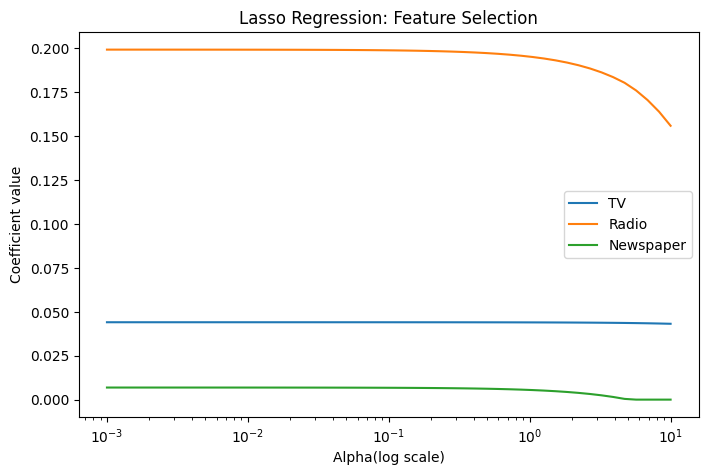

In [178]:
#Generate alpha values on log scale
alphas = np.logspace(-3, 1, 50)

#Store coefficients
coefficients_path = []

for alpha_value in alphas:
  lasso_model = Lasso(alpha=alpha_value, max_iter=10000)
  lasso_model.fit(x_train, y_train)
  coefficients_path.append(lasso_model.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {lasso_model.coef_}") #Printing coefficients

coefficients_path = np.array(coefficients_path) #Convert to numpy array

#plot
plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale('log')
plt.xlabel('Alpha(log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regression: Feature Selection')
plt.legend(X.columns)